## **Gradiente Descendente Estocástico**

O GDE não utiliza todos os dados presentes no dataset para o cáculo do gradiente, mas sim um pequeno subconjunto dos dados.

NO GDE, escolhe-se de forma aleatória uma amostra:

$$
i_t \sim \mathcal{U}\{1,2,\ldots,N\}
$$

E ao invés de calcular o gradiente completo (como ocorre no GD), calcula-se:

$$
\mathbf{\theta}^{(t+1)} = \mathbf{\theta}^{(t)} - \eta \cdot \nabla L_{i_t}\left(\mathbf{\theta}^{(t)}\right)
$$

#### **Mini-Batch**

Na prática, utiliza-se um subconjunto pequeno de amostras, chamado de **Mini-Bach**, $B_t$.

Considere ainda o dataset:

$$
V = \{(\mathbf{x}_i, y_i)\}_{i=1}^{N}
\quad \text{onde }
\mathbf{x}_i \in \mathbb{R}^{D}
\text{ e }
y_i \in \mathbb{R}
$$

o Mini-Batch é o conjunto aleatoriamente definido a cada iteração $t$ definido por:

$$
B_t \subset \{1,2,\ldots,N\}, \qquad |B_t| = m, \quad 1 \le m < N .
$$

tal que o GDE é calculado do seguinte modo:

$$
\mathbf{\theta}^{(t+1)} = \mathbf{\theta}^{(t)} - \eta \cdot \frac{1}{|B_t|} \cdot \displaystyle\sum_{i \in B_t} \nabla L_i\left(\mathbf{\theta}^{(t)}\right)
$$

## **Aplicação do Gradiente Descendente Estocástico**

Vamos aplicar o método do GDE para tarefa de **regressão** usando **Regressão Linear** no dataset **California Housing**.

#### **Pré-processamento dos dados**

In [270]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing

In [271]:
housing = fetch_california_housing()

X = housing.data
y = housing.target

df = pd.DataFrame(X, columns=housing.feature_names)
df["target"] = y

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [272]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (16512, 8)
Teste: (4128, 8)


In [273]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = np.array(X_train)
X_test = np.array(X_test)

y_train = np.array(y_train)
y_test = np.array(y_test)

In [274]:
def add_bias(X):
    ones = np.ones((X.shape[0], 1))
    return np.hstack((ones, X))

X_train = add_bias(X_train)
X_test = add_bias(X_test)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (16512, 9)
Teste: (4128, 9)


In [275]:
n_features = X_train.shape[1]

beta = np.random.randn(n_features)

#### **Implementação do GDE e da Regressão Linear**

Precisamos lembrar que a Regressão linear utiliza como função de perda o **MSE (Mean Squared Error)**:

$$
L(\theta) = \dfrac{1}{N}\sum_{i=1}^{N} (\mathbf{x}_i^{\top}\theta - y_i)^{2}
$$

Porém, dado que estamos usado o GDE, vamos definir função de perda associada a uma amostra $i_t$:

$$
L_i(\theta) = (\mathbf{x}_i^{\top}\theta - y_i)^{2}
$$

Assim, segue que:

$$
\nabla L(\theta) = 2(\mathbf{x}_i^{\top}\theta - y_i) \cdot \mathbf{x}_i
$$

O método do GDE que possui o seguite formato:

$$
\mathbf{\theta}^{(t+1)} = \mathbf{\theta}^{(t)} - \eta \cdot  2(\mathbf{x}_i^{\top}\theta - y_i) \cdot \mathbf{x}_i
$$

Substituindo $\nabla L_i(\theta)$, segue que:

$$
\mathbf{\theta}^{(t+1)} = \mathbf{\theta}^{(t)} - \eta \cdot 2(\mathbf{x}_i^{\top}\theta^{(t)} - y_i) \cdot \mathbf{x}_i
$$

Usando mini-bach, expressamos o GDE da seguinte forma:

$$
\mathbf{\theta}^{(t+1)} = \mathbf{\theta}^{(t)} - \eta \cdot \frac{2}{|B_t|} \cdot \displaystyle\sum_{i \in B_t} (\mathbf{x}_i^{\top}\theta^{(t)} - y_i) \cdot \mathbf{x}_i
$$

#### **Implementando o GDE com Mini-Batch**

In [276]:
def predict(X, beta):
    return X @ beta

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def train_gde_mini_batch(X, y, beta, eta=0.01, epochs=100, batch_size=32):

    n_samples = X.shape[0]
    loss_history = []

    for epoch in range(epochs):

        indices = np.random.permutation(n_samples)

        for start in range(0, n_samples, batch_size):

            batch_idx = indices[start:start+batch_size]

            Xb = X[batch_idx]
            yb = y[batch_idx]

            error = Xb @ beta - yb

            gradient = (Xb @ beta - yb) @ Xb

            beta = beta - eta * (2 / len(batch_idx)) * gradient

        y_epoch_pred = predict(X, beta)
        loss = mse(y, y_epoch_pred)

        loss_history.append(loss)

        if epoch % 10 == 0:
            print(f"Epoch {epoch} | Loss: {loss:.4f}")

    return beta, loss_history

In [277]:
beta = np.random.randn(X_train.shape[1])

beta, loss_history = train_gde_mini_batch(
    X_train,
    y_train,
    beta,
    epochs=100,
    eta = 0.005,
    batch_size=32
)

Epoch 0 | Loss: 0.8823
Epoch 10 | Loss: 0.5190
Epoch 20 | Loss: 0.5218
Epoch 30 | Loss: 0.5203
Epoch 40 | Loss: 0.5195
Epoch 50 | Loss: 0.5185
Epoch 60 | Loss: 0.5185
Epoch 70 | Loss: 0.5254
Epoch 80 | Loss: 0.5213
Epoch 90 | Loss: 0.5190


In [278]:
y_pred_test = predict(X_test, beta)

test_mse = mse(y_test, y_pred_test)

print("Test MSE:", test_mse)

Test MSE: 0.5518762091442804


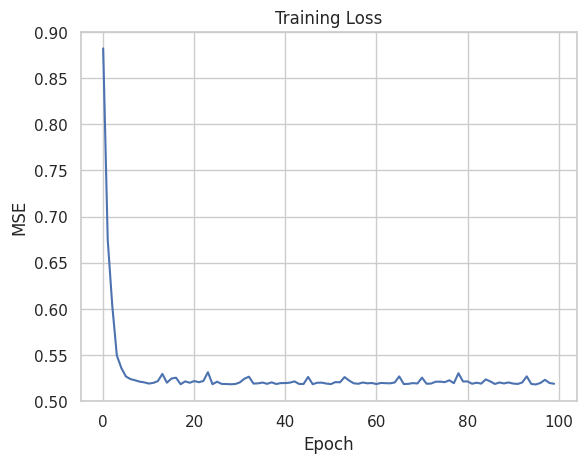

In [279]:
import matplotlib.pyplot as plt

plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Training Loss")
plt.show()

#### **Visualização dos dados com PCA**

In [280]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train)

In [281]:
pca_df = pd.DataFrame(X_train_pca, columns=["PC1", "PC2"])
pca_df["target"] = y_train

print(pca_df)

            PC1       PC2  target
0     -1.776074  0.781638   1.030
1     -1.112383 -0.088912   3.821
2      0.023500  0.412500   1.726
3     -1.860040  0.273234   0.934
4      0.601021 -0.408421   0.965
...         ...       ...     ...
16507 -0.739767  0.744748   2.292
16508 -0.663522  1.108900   0.978
16509 -1.130830 -0.042678   2.221
16510  1.343795 -0.134703   2.835
16511  0.652861 -2.044722   3.250

[16512 rows x 3 columns]


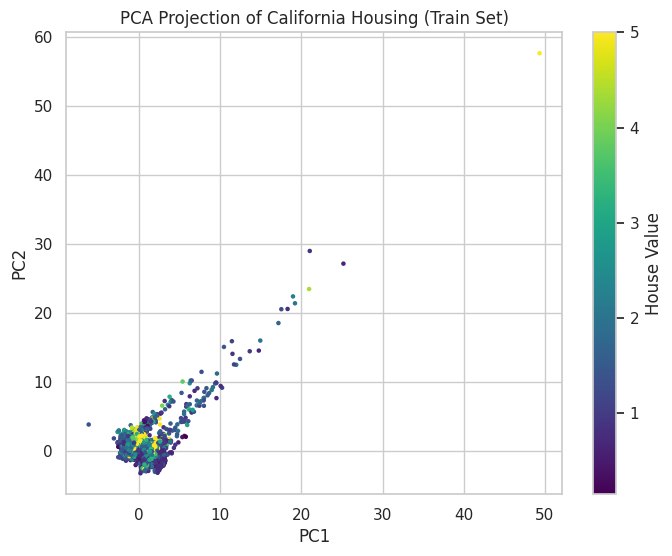

In [282]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_train_pca[:,0],
    X_train_pca[:,1],
    c=y_train,
    cmap="viridis",
    s=5
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection of California Housing (Train Set)")
plt.colorbar(label="House Value")

plt.show()